In [12]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O 
import matplotlib.pyplot as plt
import seaborn as sns

#machine learning 
from sklearn.model_selection import train_test_split #to split data (train,test)
from sklearn.preprocessing import LabelEncoder, StandardScaler #to convert cat
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix #to calcualte acc &f1
from sklearn.ensemble import RandomForestClassifier #model
from sklearn.preprocessing import RobustScaler #normaliza outliers
from sklearn.metrics import classification_report
from sklearn.feature_extraction.text import TfidfVectorizer #nlp model for text
from sklearn.linear_model import LogisticRegression #model



import warnings
warnings.filterwarnings('ignore')

import os
for dirname, _, filenames in os.walk('/input-data/'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [13]:
from pathlib import Path
print("CWD:", Path.cwd())
print("Expected path exists?:", (Path("/Users/avirup.dandapat/Desktop/neuralnetworproject/inputdata")/"multilingual_mobile_app_reviews_2025.csv").exists())


CWD: /Users/avirup.dandapat/Desktop/neuralnetworproject/NLP
Expected path exists?: True


In [14]:
#read data files
df=pd.read_csv('/Users/avirup.dandapat/Desktop/neuralnetworproject/inputdata/multilingual_mobile_app_reviews_2025.csv')
#to show frist 5 row in data
df.head()

,review_id,user_id,app_name,app_category,review_text,review_language,rating,review_date,verified_purchase,device_type,num_helpful_votes,user_age,user_country,user_gender,app_version
0,1,1967825,MX Player,Travel & Local,Qui doloribus consequuntur. Perspiciatis tempo...,no,1.3,2024-10-09 19:26:40,True,Android Tablet,65,14.0,China,Female,1.4
1,2,9242600,Tinder,Navigation,"Great app but too many ads, consider premium v...",ru,1.6,2024-06-21 17:29:40,True,iPad,209,18.0,Germany,Male,8.9
2,3,7636477,Netflix,Dating,The interface could be better but overall good...,es,3.6,2024-10-31 13:47:12,True,iPad,163,67.0,Nigeria,Male,2.8.37.5926
3,4,209031,Venmo,Productivity,"Latest update broke some features, please fix ...",vi,3.8,2025-03-12 06:16:22,True,iOS,664,66.0,India,Female,10.2
4,5,7190293,Google Drive,Education,"Perfect for daily use, highly recommend to eve...",tl,3.2,2024-04-21 03:48:27,True,iPad,1197,40.0,South Korea,Prefer not to say,4.7


In [15]:
#show missing value in data
print(f"Missing Value = {df.isnull().sum()}")

#show duplicated value
print(f'Duplicated = {df.duplicated().sum()}')

#the shape of data
print (f'Shape = {df.shape}')

Missing Value = review_id              0
user_id                0
app_name               0
app_category           0
review_text           59
review_language        0
rating                37
review_date            0
verified_purchase      0
device_type            0
num_helpful_votes      0
user_age               0
user_country          41
user_gender          587
app_version           30
dtype: int64
Duplicated = 0
Shape = (2514, 15)


In [16]:
#show NULL value
data_null = round(df.isna().sum() / df.shape[0] * 100, 2)
data_null.to_frame(name = 'percent NULL data (%)')

,percent NULL data (%)
review_id,0.00
user_id,0.00
app_name,0.00
app_category,0.00
review_text,2.35
review_language,0.00
rating,1.47
review_date,0.00
verified_purchase,0.00
device_type,0.00


In [17]:
#delete unused in data
df.drop(['user_gender'], axis=1, inplace=True)

In [18]:
#show information about data 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2514 entries, 0 to 2513
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   review_id          2514 non-null   int64  
 1   user_id            2514 non-null   int64  
 2   app_name           2514 non-null   object 
 3   app_category       2514 non-null   object 
 4   review_text        2455 non-null   object 
 5   review_language    2514 non-null   object 
 6   rating             2477 non-null   float64
 7   review_date        2514 non-null   object 
 8   verified_purchase  2514 non-null   bool   
 9   device_type        2514 non-null   object 
 10  num_helpful_votes  2514 non-null   int64  
 11  user_age           2514 non-null   float64
 12  user_country       2473 non-null   object 
 13  app_version        2484 non-null   object 
dtypes: bool(1), float64(2), int64(3), object(8)
memory usage: 257.9+ KB


In [19]:
#describe data
df.describe()

,review_id,user_id,rating,num_helpful_votes,user_age
count,2514.000000,2.514000e+03,2477.000000,2514.000000,2514.000000
mean,1257.500000,5.080737e+06,3.021034,616.704057,44.247812
std,725.873612,2.846939e+06,1.149955,363.745326,18.372290
min,1.000000,1.005990e+05,1.000000,0.000000,13.000000
25%,629.250000,2.595184e+06,2.100000,287.250000,28.000000
50%,1257.500000,5.059846e+06,3.000000,620.000000,44.000000
75%,1885.750000,7.571874e+06,4.000000,920.750000,60.000000
max,2514.000000,9.995027e+06,5.000000,1249.000000,75.000000


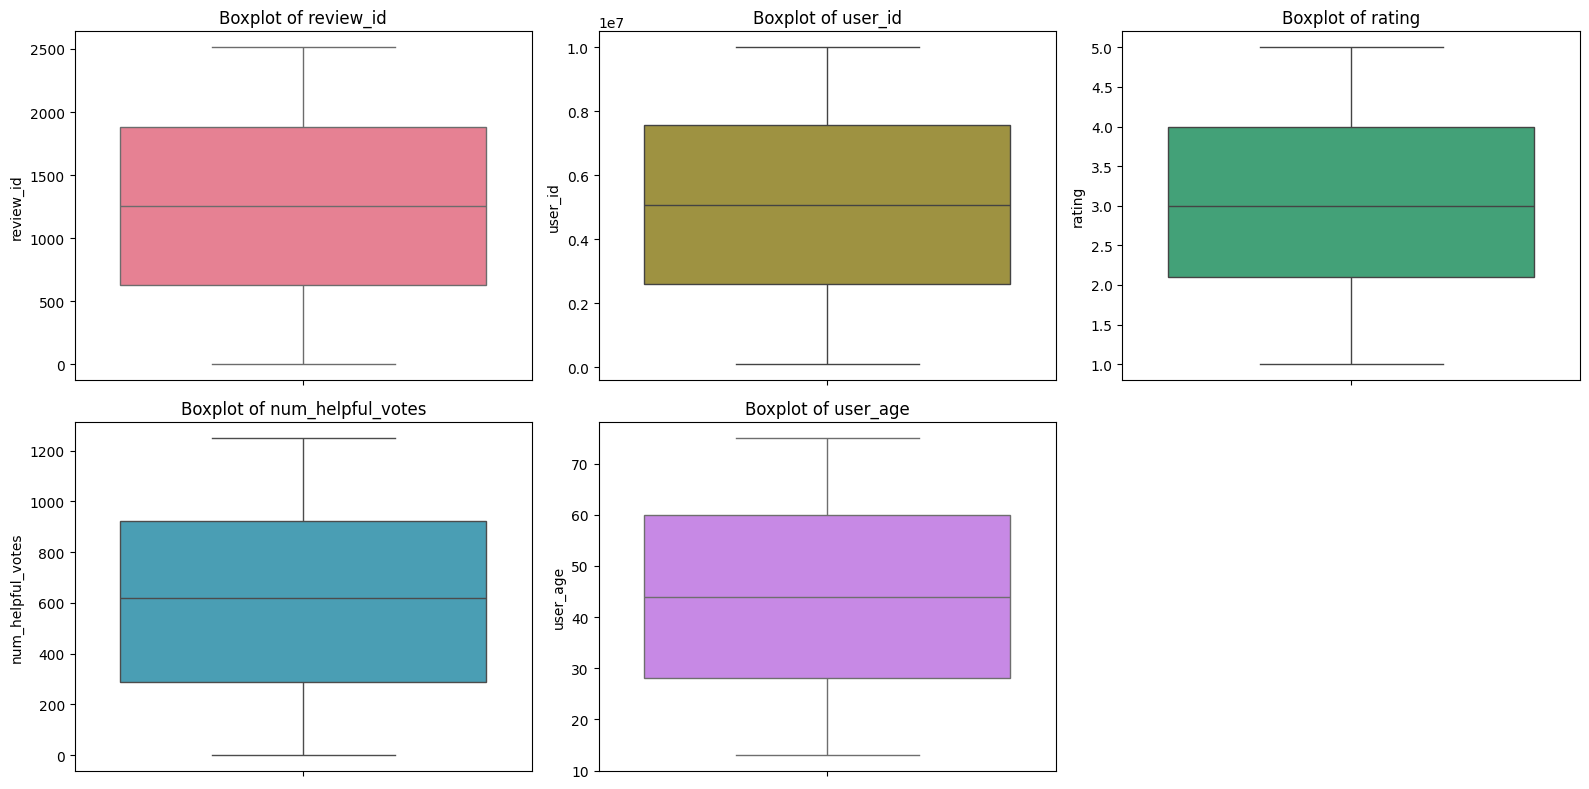

In [20]:
#numerical analysis
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Define color palette
palette = sns.color_palette("husl", len(numerical_cols))

#to show Outliers in data 
plt.figure(figsize=(16, 8))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col], color=palette[i-1])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

In [21]:
#handling missing values in data

# Fill missing with "Unknown" for categorical columns
df['user_country'] = df['user_country'].fillna('Unknown')
df['app_version'] = df['app_version'].fillna('Unknown')

In [22]:
# Fill missing with "missing" for review_text 
df['review_text'] = df['review_text'].fillna('missing')

In [23]:
# Fill missing with 0 for review_text 

df['rating'] = df['rating'].fillna(0)

In [24]:
#show missing value after handling
df.isnull().sum()

review_id            0
user_id              0
app_name             0
app_category         0
review_text          0
review_language      0
rating               0
review_date          0
verified_purchase    0
device_type          0
num_helpful_votes    0
user_age             0
user_country         0
app_version          0
dtype: int64

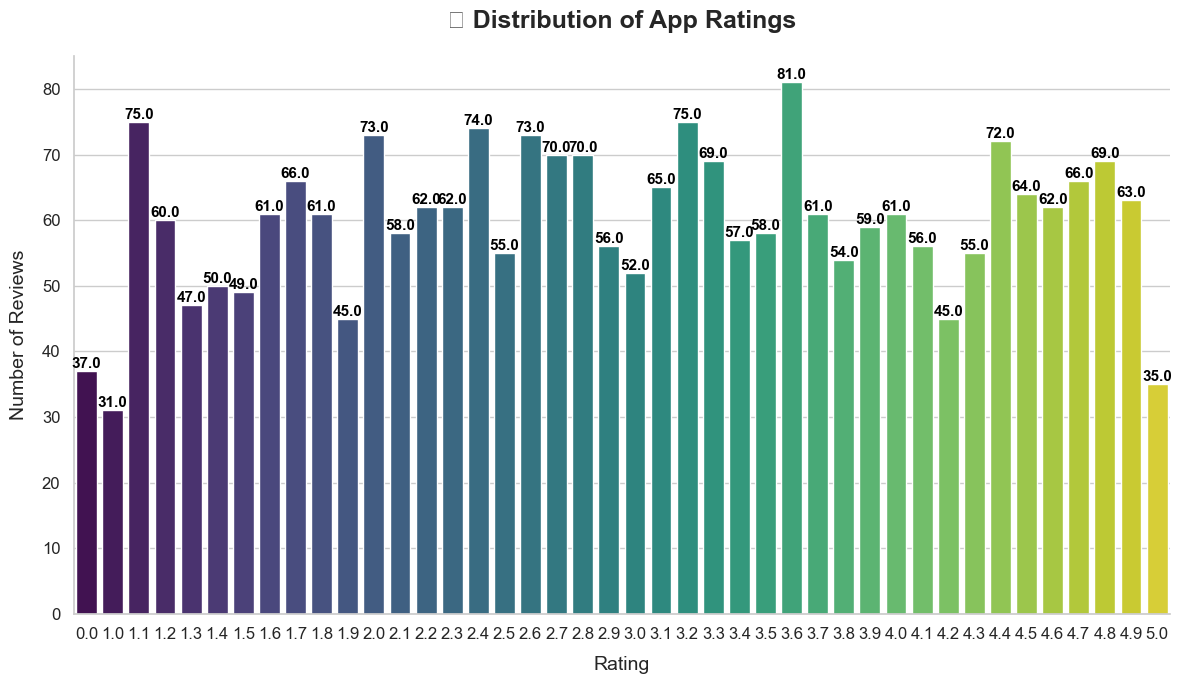

In [25]:
#show the rating after handling
# Set style
sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 7))

# Countplot with palette
sns.countplot(
    data=df,
    x="rating",
    order=sorted(df["rating"].unique()),
    palette="viridis"
)

# Titles and labels
plt.title("⭐ Distribution of App Ratings", fontsize=18, fontweight='bold', pad=20)
plt.xlabel("Rating", fontsize=14, labelpad=10)
plt.ylabel("Number of Reviews", fontsize=14, labelpad=10)

# Rotate x labels if needed
plt.xticks(rotation=0, fontsize=12)
plt.yticks(fontsize=12)

# Add value labels on top of bars
for p in plt.gca().patches:
    height = p.get_height()
    plt.gca().annotate(
        f'{height:,}', 
        (p.get_x() + p.get_width() / 2., height),
        ha='center', va='bottom',
        fontsize=11, fontweight='bold', color='black'
    )

# Clean look
sns.despine()
plt.tight_layout()
plt.show()

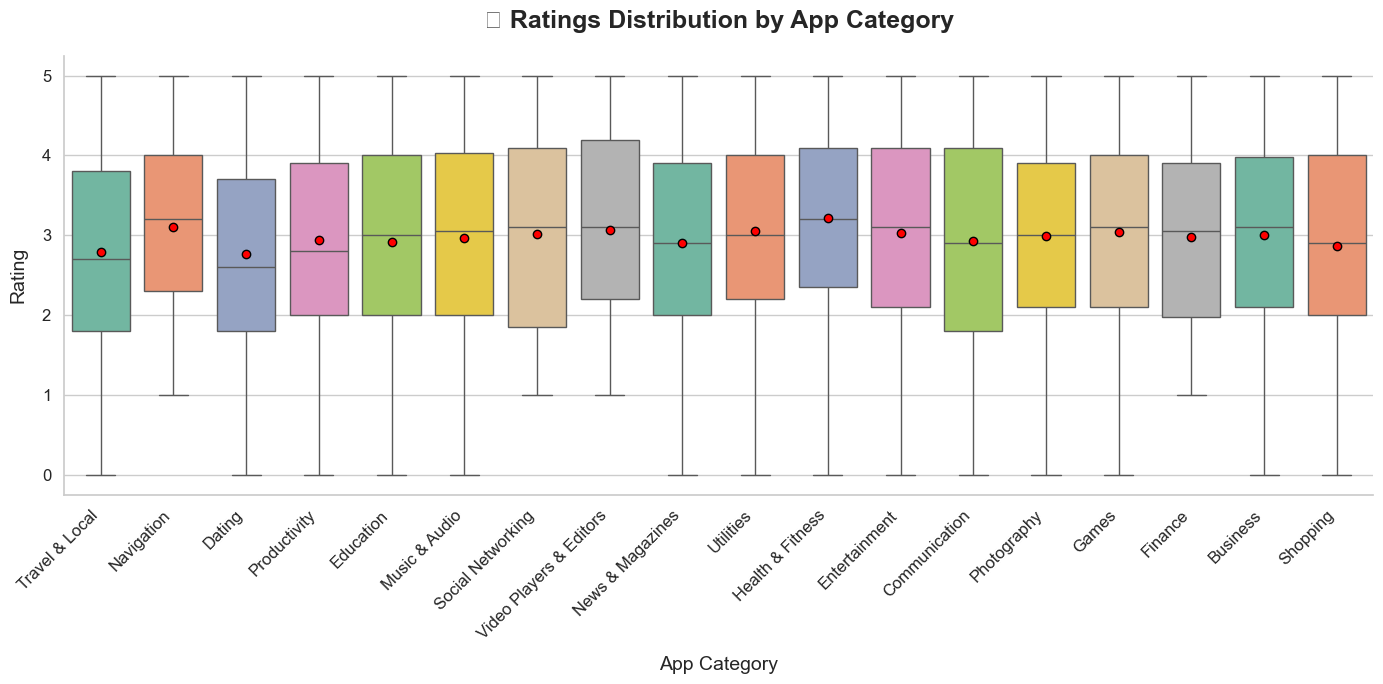

In [26]:
#ٌRatings Distribution by App Category

# Set style
sns.set_theme(style="whitegrid")

plt.figure(figsize=(14, 7))

# Boxplot with better palette
sns.boxplot(
    data=df,
    x="app_category",
    y="rating",
    palette="Set2",
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"red", "markeredgecolor":"black"}
)

# Titles and labels
plt.title("📊 Ratings Distribution by App Category", fontsize=18, fontweight='bold', pad=20)
plt.xlabel("App Category", fontsize=14, labelpad=10)
plt.ylabel("Rating", fontsize=14, labelpad=10)

# Rotate x-axis labels for clarity
plt.xticks(rotation=45, ha="right", fontsize=12)
plt.yticks(fontsize=12)

# Clean look
sns.despine()
plt.tight_layout()
plt.show()

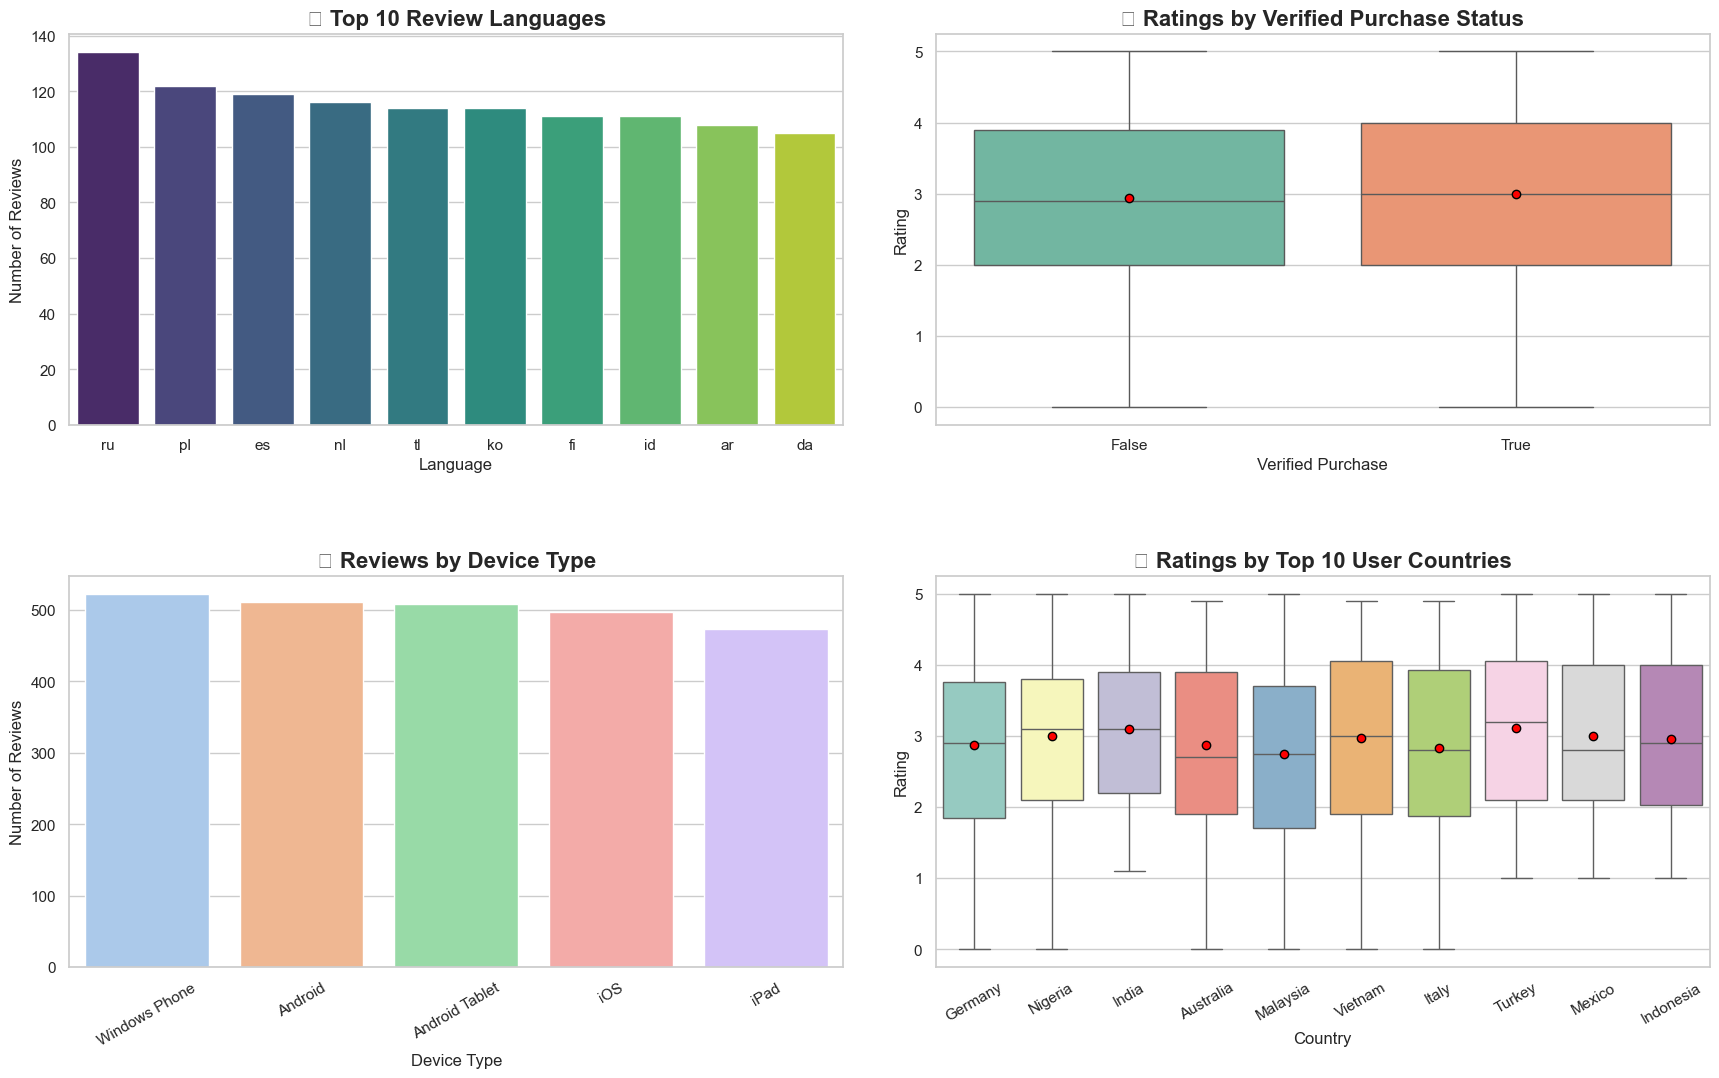

In [27]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(3, 2, figsize=(18, 16))
axes = axes.flatten()

# 1. Top 10 Review Languages
lang_counts = df["review_language"].value_counts().head(10)
sns.barplot(
    x=lang_counts.index, y=lang_counts.values, palette="viridis", ax=axes[0]
)
axes[0].set_title("🌍 Top 10 Review Languages", fontsize=16, fontweight='bold')
axes[0].set_xlabel("Language", fontsize=12)
axes[0].set_ylabel("Number of Reviews", fontsize=12)

# 2. Ratings by Verified Purchase Status
sns.boxplot(
    data=df, x="verified_purchase", y="rating", palette="Set2", ax=axes[1],
    showmeans=True, meanprops={"marker":"o","markerfacecolor":"red","markeredgecolor":"black"}
)
axes[1].set_title("✅ Ratings by Verified Purchase Status", fontsize=16, fontweight='bold')
axes[1].set_xlabel("Verified Purchase", fontsize=12)
axes[1].set_ylabel("Rating", fontsize=12)

# 3. Reviews by Device Type
sns.countplot(
    data=df, x="device_type", order=df["device_type"].value_counts().index,
    palette="pastel", ax=axes[2]
)
axes[2].set_title("📱 Reviews by Device Type", fontsize=16, fontweight='bold')
axes[2].set_xlabel("Device Type", fontsize=12)
axes[2].set_ylabel("Number of Reviews", fontsize=12)
axes[2].tick_params(axis='x', rotation=30)

# 4. Ratings by Top 10 User Countries
top_countries = df["user_country"].value_counts().head(10).index
sns.boxplot(
    data=df[df["user_country"].isin(top_countries)],
    x="user_country", y="rating", palette="Set3", ax=axes[3],
    showmeans=True, meanprops={"marker":"o","markerfacecolor":"red","markeredgecolor":"black"}
)
axes[3].set_title("🌎 Ratings by Top 10 User Countries", fontsize=16, fontweight='bold')
axes[3].set_xlabel("Country", fontsize=12)
axes[3].set_ylabel("Rating", fontsize=12)
axes[3].tick_params(axis='x', rotation=30)


# Remove unused subplot (bottom-right)
fig.delaxes(axes[4])
fig.delaxes(axes[5])


# Adjust layout
plt.tight_layout(pad=3.0)
plt.show()

In [28]:
!pip install nltk
!pip install --upgrade pip

In [29]:
import sys, subprocess
subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", "nltk"])

import nltk
#nltk.download("vader_lexicon", quiet=True)


In [30]:
#Using VADER (fast & good for short reviews):
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer


In [31]:
import sys, subprocess
subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", "vaderSentiment"])

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()
print(sia.polarity_scores("Loved the UI, but it crashed twice."))


{'neg': 0.0, 'neu': 0.71, 'pos': 0.29, 'compound': 0.3506}


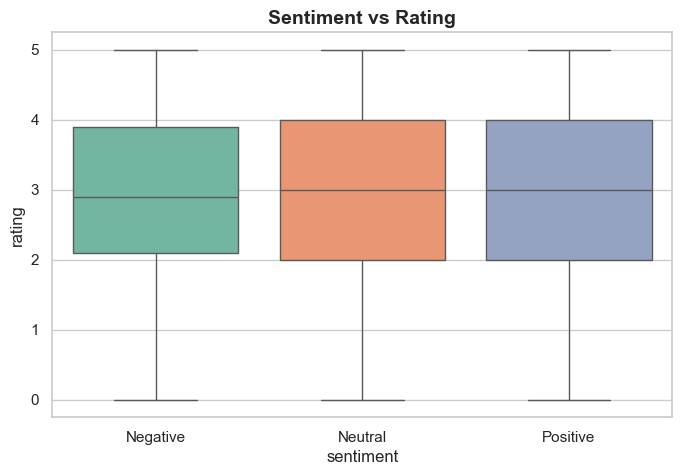

In [32]:
##1. Sentiment Analysis

sia = SentimentIntensityAnalyzer()
df["sentiment_score"] = df["review_text"].apply(lambda x: sia.polarity_scores(str(x))["compound"])

# Categorize sentiment
df["sentiment"] = pd.cut(
    df["sentiment_score"], 
    bins=[-1, -0.05, 0.05, 1], 
    labels=["Negative", "Neutral", "Positive"]
)

# Compare sentiment vs rating
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="sentiment", y="rating", palette="Set2")
plt.title("Sentiment vs Rating", fontsize=14, fontweight="bold")
plt.show()

In [34]:
## 2. Topic Modeling
import sys, subprocess
subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", "gensim", "smart_open"])

from gensim import corpora, models
from gensim.parsing.preprocessing import preprocess_string, strip_punctuation, strip_numeric, strip_multiple_whitespaces, strip_short


from sklearn.feature_extraction.text import CountVectorizer

# Tokenize reviews
vectorizer = CountVectorizer(stop_words="english", max_df=0.7, min_df=5)
X = vectorizer.fit_transform(df["review_text"].dropna())

# Convert to gensim corpus
corpus = [dict(zip(vectorizer.get_feature_names_out(), row.toarray().flatten())) 
          for row in X]

# Gensim dictionary
dictionary = corpora.Dictionary([list(c.keys()) for c in corpus])

# Build LDA model
texts = [str(r).split() for r in df["review_text"].dropna()]
dictionary = corpora.Dictionary(texts)
corpus = [dictionary.doc2bow(text) for text in texts]
lda_model = models.LdaModel(corpus, num_topics=5, id2word=dictionary, passes=10)

print("Top Topics:")
for idx, topic in lda_model.print_topics(num_words=5):
    print(f"Topic {idx}: {topic}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.1/24.1 MB 2.0 MB/s  0:00:12 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [gensim]2m1/2 [gensim]
Top Topics:
Topic 0: 0.062*"but" + 0.033*"many" + 0.033*"app" + 0.033*"premium" + 0.033*"ads,"
Topic 1: 0.050*"in" + 0.046*"too" + 0.046*"stability." + 0.046*"Crashes" + 0.046*"needs"
Topic 2: 0.041*"and" + 0.041*"feature" + 0.041*"regular" + 0.041*"updates." + 0.041*"Excellent"
Topic 3: 0.026*"the" + 0.026*"amazing!" + 0.026*"is" + 0.026*"features." + 0.026*"This"
Topic 4: 0.039*"throughout." + 0.039*"design" + 0.039*"performance" + 0.039*"User-friendly" + 0.039*"smooth"


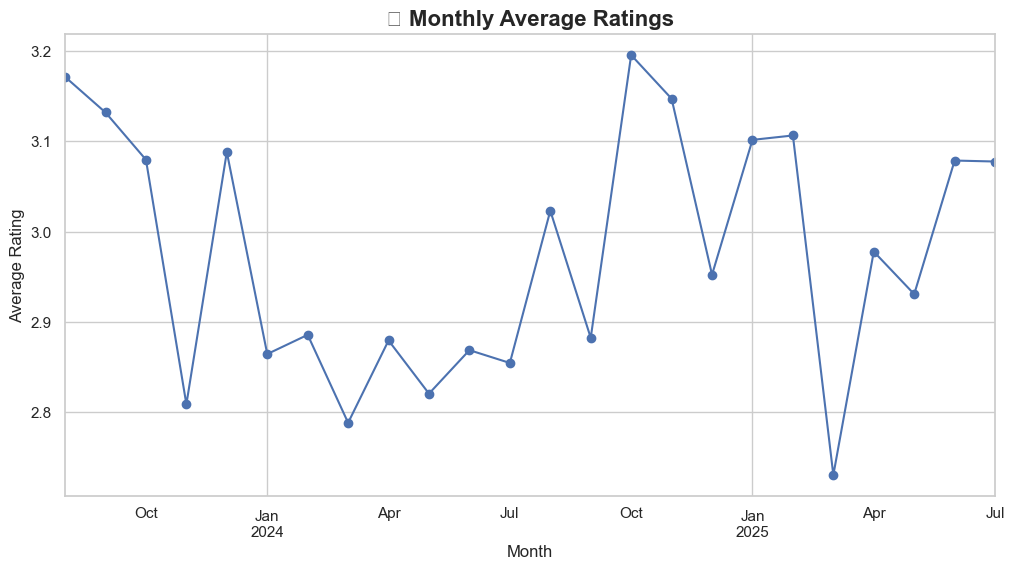

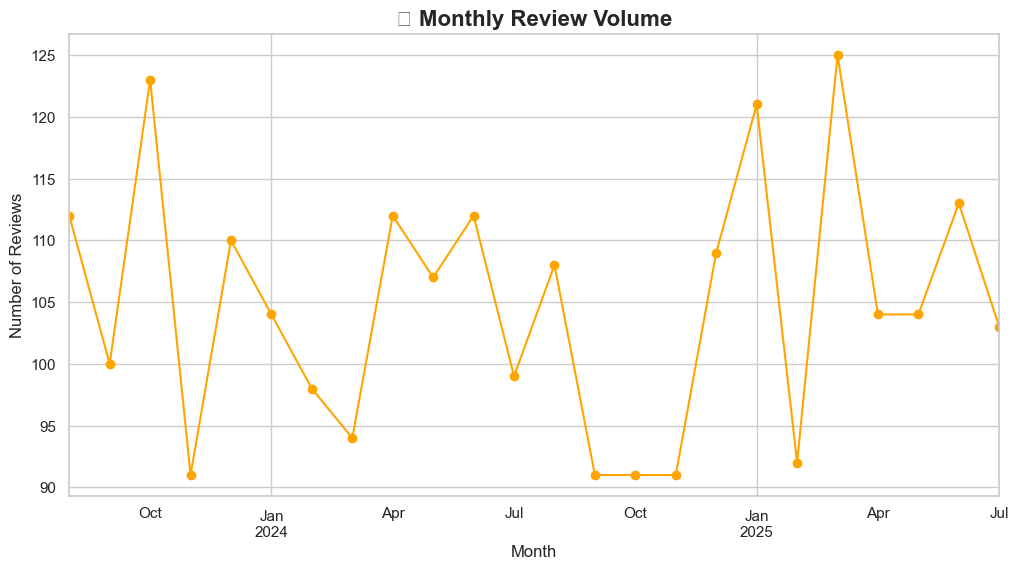

In [35]:
#Time-Series Trend for
#Monthly average rating
#Review volume trend


df["review_date"] = pd.to_datetime(df["review_date"])

# Monthly average rating
monthly_ratings = df.groupby(df["review_date"].dt.to_period("M"))["rating"].mean()

plt.figure(figsize=(12,6))
monthly_ratings.plot(marker="o")
plt.title("📈 Monthly Average Ratings", fontsize=16, fontweight="bold")
plt.ylabel("Average Rating")
plt.xlabel("Month")
plt.show()

# Review volume trend
monthly_counts = df.groupby(df["review_date"].dt.to_period("M"))["review_id"].count()

plt.figure(figsize=(12,6))
monthly_counts.plot(marker="o", color="orange")
plt.title("📝 Monthly Review Volume", fontsize=16, fontweight="bold")
plt.ylabel("Number of Reviews")
plt.xlabel("Month")
plt.show()

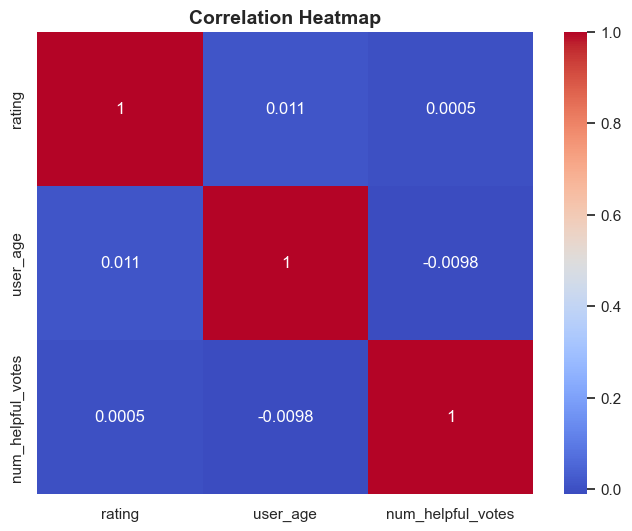

In [36]:
#Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df[["rating", "user_age", "num_helpful_votes"]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap", fontsize=14, fontweight="bold")
plt.show()

In [37]:
# Example regression model
import statsmodels.api as sm

X = df[["user_age", "num_helpful_votes"]].fillna(0)
y = df["rating"].fillna(df["rating"].mean())

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 rating   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.1660
Date:                Tue, 26 Aug 2025   Prob (F-statistic):              0.847
Time:                        13:47:58   Log-Likelihood:                -4020.8
No. Observations:                2514   AIC:                             8048.
Df Residuals:                    2511   BIC:                             8065.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 2.9422      0.07

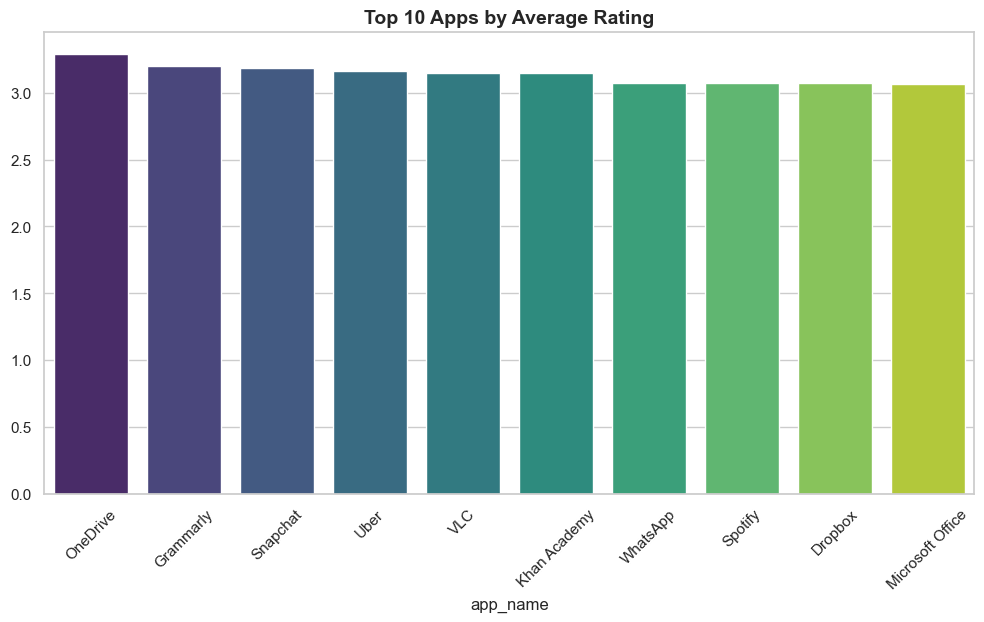

In [38]:
# Average rating by app
app_ratings = df.groupby("app_name")["rating"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=app_ratings.index, y=app_ratings.values, palette="viridis")
plt.title("Top 10 Apps by Average Rating", fontsize=14, fontweight="bold")
plt.xticks(rotation=45)
plt.show()

In [39]:
#check accuracy using ML model¶
#frist we must use copy from origenal dataframe 
df_encoded = df.copy()
#define labalencoder
le = LabelEncoder()

In [40]:
# encoding or convert object to num 

for col in df_encoded.select_dtypes(include=["object"]).columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

In [41]:
df_encoded.head()

,review_id,user_id,app_name,app_category,review_text,review_language,rating,review_date,verified_purchase,device_type,num_helpful_votes,user_age,user_country,app_version,sentiment_score,sentiment
0,1,1967825,18,15,416,14,1.3,2024-10-09 19:26:40,True,1,65,14.0,4,46,0.0000,Neutral
1,2,9242600,30,9,221,17,1.6,2024-06-21 17:29:40,True,4,209,18.0,6,1512,0.3716,Positive
2,3,7636477,20,2,507,4,3.6,2024-10-31 13:47:12,True,4,163,67.0,13,876,0.7003,Positive
3,4,209031,35,12,279,22,3.8,2025-03-12 06:16:22,True,3,664,66.0,7,138,-0.1280,Negative
4,5,7190293,11,3,371,20,3.2,2024-04-21 03:48:27,True,4,1197,40.0,17,1075,0.7574,Positive


In [42]:
#frist solving date
df_encoded["review_date"] = pd.to_datetime(df_encoded["review_date"], errors="coerce")

# split date to year,month ,day 
df_encoded["year"] = df_encoded["review_date"].dt.year
df_encoded["month"] = df_encoded["review_date"].dt.month
df_encoded["day"] = df_encoded["review_date"].dt.day

In [43]:
#sec solving change true = 1 , false = 0
df_encoded["verified_purchase"] = df_encoded["verified_purchase"].map({"T": 1, "F": 0})

In [44]:
#3th solve sentiment to 0,1,2
sentiment_mapping = {"negative": 0, "neutral": 1, "positive": 2}
df_encoded["sentiment"] = df_encoded["sentiment"].map(sentiment_mapping)

In [45]:
le = LabelEncoder()
for col in df_encoded.select_dtypes(include=["object"]).columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

df_encoded.head()

,review_id,user_id,app_name,app_category,review_text,review_language,rating,review_date,verified_purchase,device_type,num_helpful_votes,user_age,user_country,app_version,sentiment_score,sentiment,year,month,day
0,1,1967825,18,15,416,14,1.3,2024-10-09 19:26:40,NaN,1,65,14.0,4,46,0.0000,NaN,2024,10,9
1,2,9242600,30,9,221,17,1.6,2024-06-21 17:29:40,NaN,4,209,18.0,6,1512,0.3716,NaN,2024,6,21
2,3,7636477,20,2,507,4,3.6,2024-10-31 13:47:12,NaN,4,163,67.0,13,876,0.7003,NaN,2024,10,31
3,4,209031,35,12,279,22,3.8,2025-03-12 06:16:22,NaN,3,664,66.0,7,138,-0.1280,NaN,2025,3,12
4,5,7190293,11,3,371,20,3.2,2024-04-21 03:48:27,NaN,4,1197,40.0,17,1075,0.7574,NaN,2024,4,21


In [46]:
print("🔎 Verified_purchase unique values:", df["verified_purchase"].unique())
print("🔎 Sentiment unique values:", df["sentiment"].unique())

🔎 Verified_purchase unique values: [ True False]
🔎 Sentiment unique values: ['Neutral', 'Positive', 'Negative']
Categories (3, object): ['Negative' < 'Neutral' < 'Positive']


In [47]:
# encoding verified_purchase (True/False → 1/0)
df_encoded["verified_purchase"] = df["verified_purchase"].map({True: 1, False: 0})

# encoding sentiment (Negative / Neutral / Positive → 0/1/2)
sentiment_mapping = {"Negative": 0, "Neutral": 1, "Positive": 2}
df_encoded["sentiment"] = df["sentiment"].map(sentiment_mapping)

print("✅ after solving:")
print(df_encoded[["verified_purchase", "sentiment"]].head())

✅ after solving:
   verified_purchase sentiment
0                  1         1
1                  1         2
2                  1         2
3                  1         0
4                  1         2


In [48]:
df_encoded.head()

,review_id,user_id,app_name,app_category,review_text,review_language,rating,review_date,verified_purchase,device_type,num_helpful_votes,user_age,user_country,app_version,sentiment_score,sentiment,year,month,day
0,1,1967825,18,15,416,14,1.3,2024-10-09 19:26:40,1,1,65,14.0,4,46,0.0000,1,2024,10,9
1,2,9242600,30,9,221,17,1.6,2024-06-21 17:29:40,1,4,209,18.0,6,1512,0.3716,2,2024,6,21
2,3,7636477,20,2,507,4,3.6,2024-10-31 13:47:12,1,4,163,67.0,13,876,0.7003,2,2024,10,31
3,4,209031,35,12,279,22,3.8,2025-03-12 06:16:22,1,3,664,66.0,7,138,-0.1280,0,2025,3,12
4,5,7190293,11,3,371,20,3.2,2024-04-21 03:48:27,1,4,1197,40.0,17,1075,0.7574,2,2024,4,21


In [49]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2514 entries, 0 to 2513
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   review_id          2514 non-null   int64         
 1   user_id            2514 non-null   int64         
 2   app_name           2514 non-null   int64         
 3   app_category       2514 non-null   int64         
 4   review_text        2514 non-null   int64         
 5   review_language    2514 non-null   int64         
 6   rating             2514 non-null   float64       
 7   review_date        2514 non-null   datetime64[ns]
 8   verified_purchase  2514 non-null   int64         
 9   device_type        2514 non-null   int64         
 10  num_helpful_votes  2514 non-null   int64         
 11  user_age           2514 non-null   float64       
 12  user_country       2514 non-null   int64         
 13  app_version        2514 non-null   int64         
 14  sentimen

In [50]:
#change type about sentiment to int
df_encoded["sentiment"] = df_encoded["sentiment"].astype(int)

In [51]:
#check it 
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2514 entries, 0 to 2513
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   review_id          2514 non-null   int64         
 1   user_id            2514 non-null   int64         
 2   app_name           2514 non-null   int64         
 3   app_category       2514 non-null   int64         
 4   review_text        2514 non-null   int64         
 5   review_language    2514 non-null   int64         
 6   rating             2514 non-null   float64       
 7   review_date        2514 non-null   datetime64[ns]
 8   verified_purchase  2514 non-null   int64         
 9   device_type        2514 non-null   int64         
 10  num_helpful_votes  2514 non-null   int64         
 11  user_age           2514 non-null   float64       
 12  user_country       2514 non-null   int64         
 13  app_version        2514 non-null   int64         
 14  sentimen

In [52]:
X = df_encoded.drop(columns=["sentiment", "review_date"])  
y = df_encoded["sentiment"]

In [53]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [54]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        46
           1       1.00      1.00      1.00       177
           2       1.00      1.00      1.00       280

    accuracy                           1.00       503
   macro avg       1.00      1.00      1.00       503
weighted avg       1.00      1.00      1.00       503



In [55]:
X_text = df['review_text'].fillna('')  #if found NaN value
y = df['sentiment']

# TF-IDF
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_vect = vectorizer.fit_transform(X_text)

# split Train/Test
X_train, X_test, y_train, y_test = train_test_split(
    X_vect, y, test_size=0.2, random_state=42, stratify=y
)

# simple model  
model = LogisticRegression(max_iter=500)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    Negative       1.00      0.83      0.91        54
     Neutral       0.93      1.00      0.97       169
    Positive       1.00      0.99      0.99       280

    accuracy                           0.98       503
   macro avg       0.98      0.94      0.96       503
weighted avg       0.98      0.98      0.98       503



In [56]:
# --- Clustering app reviews: text + metadata (multilingual-friendly) ---
import re
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import MiniBatchKMeans, KMeans
from sklearn.metrics import silhouette_score
from sklearn.pipeline import Pipeline

In [64]:
#read data files
df=pd.read_csv('/Users/avirup.dandapat/Desktop/neuralnetworproject/inputdata/multilingual_mobile_app_reviews_2025.csv')
#to show frist 5 row in data
#delete unused in data
df.drop(['user_gender'], axis=1, inplace=True)
df.head()

,review_id,user_id,app_name,app_category,review_text,review_language,rating,review_date,verified_purchase,device_type,num_helpful_votes,user_age,user_country,app_version
0,1,1967825,MX Player,Travel & Local,Qui doloribus consequuntur. Perspiciatis tempo...,no,1.3,2024-10-09 19:26:40,True,Android Tablet,65,14.0,China,1.4
1,2,9242600,Tinder,Navigation,"Great app but too many ads, consider premium v...",ru,1.6,2024-06-21 17:29:40,True,iPad,209,18.0,Germany,8.9
2,3,7636477,Netflix,Dating,The interface could be better but overall good...,es,3.6,2024-10-31 13:47:12,True,iPad,163,67.0,Nigeria,2.8.37.5926
3,4,209031,Venmo,Productivity,"Latest update broke some features, please fix ...",vi,3.8,2025-03-12 06:16:22,True,iOS,664,66.0,India,10.2
4,5,7190293,Google Drive,Education,"Perfect for daily use, highly recommend to eve...",tl,3.2,2024-04-21 03:48:27,True,iPad,1197,40.0,South Korea,4.7


In [65]:
# ---------- 1) Basic sanitization ----------
# Ensure types and handle missing values
df = df.copy()
df["review_text"] = df["review_text"].fillna("").astype(str)
df["review_language"] = df["review_language"].fillna("unknown").astype(str)
df["app_category"] = df["app_category"].fillna("unknown").astype(str)
df["device_type"] = df["device_type"].fillna("unknown").astype(str)
df["user_country"] = df["user_country"].fillna("unknown").astype(str)
#df["user_gender"] = df["user_gender"].fillna("unknown").astype(str)
df["verified_purchase"] = df["verified_purchase"].fillna(False).astype(bool)
for col in ["rating", "num_helpful_votes", "user_age"]:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0.0)

In [66]:
# ---------- 2) Feature engineering via ColumnTransformer ----------
# Text: character n-gram TF-IDF (robust for multilingual short texts)
text_vectorizer = TfidfVectorizer(
    analyzer="char_wb",        # char n-grams at word boundaries
    ngram_range=(3, 5),
    min_df=1,
    max_features=8000
)

categoricals = ["app_category", "review_language", "device_type", "user_country",]# "user_gender"]
# use sparse_output on 1.4+ ; fall back to sparse on older versions
try:
    cat_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=True, dtype=float)
except TypeError:
    cat_encoder = OneHotEncoder(handle_unknown="ignore", sparse=True, dtype=float)

# Numerics: scale (KMeans is distance-based)
numeric_cols = ["rating", "num_helpful_votes", "user_age"]
num_scaler = StandardScaler()  # dense output is fine for small/medium data

# Boolean: treat as numeric 0/1 then scale
bool_col = ["verified_purchase"]
bool_scaler = StandardScaler(with_mean=False)  # keep sparse-friendly behavior if needed

features = ColumnTransformer(
    transformers=[
        ("review_text", text_vectorizer, "review_text"),
        ("cats", cat_encoder, categoricals),
        ("nums", num_scaler, numeric_cols),
        ("bools", bool_scaler, bool_col),
    ],
    remainder="drop",
    verbose_feature_names_out=True,
)


In [67]:
# ---------- 3) Auto-select k (or set manually) ----------
def choose_k(X, k_min=2, k_max=8, random_state=42):
    # For very tiny datasets, cap k to n_samples-1
    n = X.shape[0]
    k_max = max(k_min, min(k_max, n - 1))
    best_k, best_score = None, -1
    for k in range(k_min, k_max + 1):
        # MiniBatchKMeans is fast and robust
        model = MiniBatchKMeans(n_clusters=k, random_state=random_state, n_init="auto")
        labels = model.fit_predict(X)
        # Need at least 2 labels to compute silhouette
        if len(set(labels)) > 1 and n >= (k + 1):
            try:
                score = silhouette_score(X, labels, metric="euclidean")
            except Exception:
                score = -1
        else:
            score = -1
        if score > best_score:
            best_k, best_score = k, score
    return best_k or max(2, min(5, n - 1))


In [70]:
# ---------- 4) Full pipeline ----------
def cluster_reviews(
    df: pd.DataFrame,
    n_clusters: int | str = "auto",
    random_state: int = 42,
    top_terms: int = 10,
    examples_per_cluster: int = 3,
):
    pipe = Pipeline(steps=[
        ("features", features),
        ("kmeans", MiniBatchKMeans(n_clusters=2, random_state=random_state, n_init="auto"))  # placeholder k
    ])

    # 4a) Fit features first to pick k if needed
    X = features.fit_transform(df)
    if n_clusters == "auto":
        k = choose_k(X)
    else:
        k = int(n_clusters)

    # 4b) Fit final model
    kmeans = MiniBatchKMeans(n_clusters=k, random_state=random_state, n_init="auto")
    labels = kmeans.fit_predict(X)

    # 4c) Attach labels
    out_df = df.copy()
    out_df["cluster"] = labels

    # 4d) Build summaries: top text features per cluster + top categorical signals
    feat_names = features.get_feature_names_out()
    centers = kmeans.cluster_centers_

    def top_feature_names_for(prefix, cluster_idx, top_n):
        # Select indices for features that start with given prefix (e.g., "review_text__")
        idxs = [i for i, name in enumerate(feat_names) if name.startswith(prefix)]
        if not idxs:
            return []
        weights = centers[cluster_idx, idxs]
        top_idx = np.argsort(weights)[-top_n:][::-1]
        selected = [feat_names[idxs[i]] for i in top_idx]
        # Trim the "review_text__" prefix and vectorizer prefix to show clean tokens
        cleaned = []
        for name in selected:
            # e.g., "review_text__tfidfvectorizer__xx" -> token "xx"
            token = re.sub(r"^review_text__.*?__", "", name)
            token = token.replace("review_text__", "")
            cleaned.append(token)
        return cleaned

    # pick top categorical signals
    def top_cat_values(cluster_idx, top_n=5):
        idxs = [i for i, name in enumerate(feat_names) if name.startswith("cats__")]
        if not idxs:
            return []
        weights = centers[cluster_idx, idxs]
        top_idx = np.argsort(weights)[-top_n:][::-1]
        return [feat_names[idxs[i]].replace("cats__", "") for i in top_idx]

    cluster_summaries = []
    # distances for picking examples
    dists = kmeans.transform(X)  # distance to each centroid
    for c in range(k):
        # top text character n-grams
        top_text = top_feature_names_for("review_text__", c, top_terms)
        top_cats = top_cat_values(c, top_n=5)

        # example rows nearest to centroid c
        nearest_idx = np.argsort(dists[:, c])[:examples_per_cluster]
        examples = out_df.iloc[nearest_idx][["review_id", "review_text", "rating", "review_language", "app_category", "num_helpful_votes"]]

        cluster_summaries.append({
            "cluster": c,
            "count": int((out_df["cluster"] == c).sum()),
            "top_text_ngrams": top_text,
            "top_categorical_signals": top_cats,
            "examples": examples,
        })

    return out_df, cluster_summaries

# ---------- 5) Run it ----------
clustered_df, summaries = cluster_reviews(df, n_clusters="auto", random_state=42, top_terms=8, examples_per_cluster=2)
#clustered_df, summaries = cluster_reviews(df, n_clusters=5, random_state=42, top_terms=8, examples_per_cluster=2)

print("Cluster sizes:")
print(clustered_df["cluster"].value_counts().sort_index(), "\n")

for s in summaries:
    print(f"=== Cluster {s['cluster']} (n={s['count']}) ===")
    print("Top text n-grams:", ", ".join(s["top_text_ngrams"]) or "(none)")
    print("Top categorical signals:", ", ".join(s["top_categorical_signals"]) or "(none)")
    print("Examples:")
    print(s["examples"].to_string(index=False))
    print()

Cluster sizes:
cluster
0     575
1    1939
Name: count, dtype: int64 

=== Cluster 0 (n=575) ===
Top text n-grams: ly ,  th, per, erf, all, eat, ate,  re
Top categorical signals: device_type_iOS, device_type_Android, device_type_Android Tablet, device_type_iPad, device_type_Windows Phone
Examples:
 review_id review_text  rating review_language     app_category  num_helpful_votes
      1323                 3.0              ms         Business                754
      1550                 2.3              th News & Magazines                577

=== Cluster 1 (n=1939) ===
Top text n-grams: ly ,  th, eat,  bu, per, erf, er , ate
Top categorical signals: device_type_Windows Phone, device_type_Android Tablet, device_type_Android, device_type_iOS, device_type_iPad
Examples:
 review_id review_text  rating review_language            app_category  num_helpful_votes
      1472                 2.7              nl Video Players & Editors                653
      2197                 3.2            